### Etape 0 Import des librairies 

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### lecture du dataset + métriques

In [51]:
df = pd.read_csv('transaction_clean.csv')
print("Shape :", df.shape)
print("Aperçu :")
print(df.head())
print("\nTypes :")
print(df.dtypes)

print("verification des valeurs manquantes")
print("Valeurs manquantes :")
print(df.isnull().sum())

Shape : (1802615, 11)
Aperçu :
  invoice_id  customer_id product_code                      product_name  \
0     513574          NaN        22382        LUNCH BAG SPACEBOY DESIGN    
1     609421          NaN        21028          PURPLE GEMSTONE BRACELET   
2     515609          NaN       47591B          SCOTTIES CHILDRENS APRON   
3     501320      15123.0        22334  DINOSAUR PARTY BAG + STICKER SET   
4     521822      12714.0        21933   PINK VINTAGE PAISLEY PICNIC BAG   

   quantity  unit_price         invoice_date         country from_store  \
0       2.0        4.21  2010-06-25 15:13:00  United Kingdom        yep   
1       2.0        8.95  2011-10-16 12:20:00  United Kingdom        yep   
2       1.0        1.66  2010-07-13 15:44:00  United Kingdom        yep   
3       8.0        1.65  2010-03-16 09:49:00  United Kingdom         no   
4       5.0        2.95  2010-09-09 10:37:00          France         no   

  retour_commande  total_price  
0             non         8.

In [52]:
df = df[df["retour_commande"] == "non"]
df = df[df["quantity"] > 0]
df = df[df["total_price"] > 0]
df = df[df["customer_id"].notna()]

In [53]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], format="%Y-%m-%d %H:%M:%S")

In [54]:
date_min = df['invoice_date'].min() 
date_max = df['invoice_date'].max()
print(f"Période couverte : {date_min} à {date_max}")    

Période couverte : 2007-07-06 12:20:00 à 2011-12-09 12:50:00


### Etape 1 split temporel

In [55]:
date_min = df["invoice_date"].min()
date_max = df["invoice_date"].max()
print(f"Dataset de {date_min.date()} à {date_max.date()}")

Dataset de 2007-07-06 à 2011-12-09


In [56]:
cutoff     = date_min + pd.DateOffset(months=36)
cutoff_end = cutoff   + pd.DateOffset(months=6)

In [57]:
obs        = df[(df["invoice_date"] >= date_min) & (df["invoice_date"] < cutoff)].copy()
target_df  = df[(df["invoice_date"] >= cutoff)   & (df["invoice_date"] < cutoff_end)].copy()

In [58]:
print(f"Période observation : {obs['invoice_date'].min().date()} a {obs['invoice_date'].max().date()}")
print(f"Période cible       : {target_df['invoice_date'].min().date()} a {target_df['invoice_date'].max().date()}")


Période observation : 2007-07-06 a 2010-07-06
Période cible       : 2010-07-06 a 2011-01-06


### Calcul de la CLV

In [59]:
clv = (
    target_df
    .groupby("customer_id")["total_price"]
    .sum()
    .reset_index()
    .rename(columns={"total_price": "clv_target"})
)
clv.head()

,customer_id,clv_target
0,12347.0,1323.32
1,12348.0,1114.96
2,12349.0,1402.62
3,12351.0,300.93
4,12352.0,343.80


In [60]:
all_customers = obs["customer_id"].unique()
clv_target = clv[clv["customer_id"].isin(all_customers)]

In [61]:
clv_target = (
    pd.DataFrame({"customer_id": all_customers})
    .merge(clv_target, on="customer_id", how="left")
    .fillna(0)
)

print(f"\nDistribution de la CLV target :")
print(clv_target["clv_target"].describe())


Distribution de la CLV target :
count     28537.000000
mean        226.911146
std        1823.610753
min           0.000000
25%           0.000000
50%           0.000000
75%          90.000000
max      179248.380000
Name: clv_target, dtype: float64


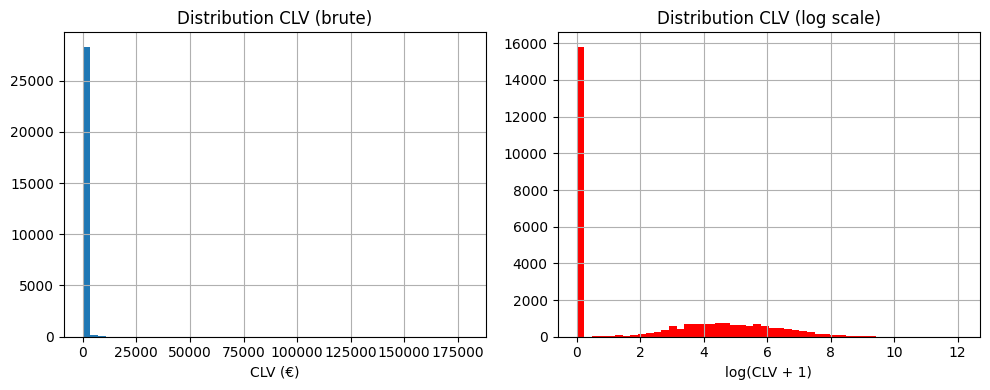

In [62]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
clv_target["clv_target"].hist(bins=50)
plt.title("Distribution CLV (brute)")
plt.xlabel("CLV (€)")
plt.subplot(1, 2, 2)
np.log1p(clv_target["clv_target"]).hist(bins=50, color="red")
plt.title("Distribution CLV (log scale)")
plt.xlabel("log(CLV + 1)")
plt.tight_layout()
plt.savefig("clv_distribution.png", dpi=100)
plt.show()

In [63]:
snapshot_date = cutoff

### Calcul des différentes features

#### Features RFM

In [64]:
recence = (
    obs.groupby("customer_id")["invoice_date"]
    .max()
    .reset_index()
)
recence["recence_jours"] = (snapshot_date - recence["invoice_date"]).dt.days
recence = recence[["customer_id", "recence_jours"]]

frequence = (
    obs.groupby("customer_id")["invoice_id"]
    .nunique()
    .reset_index()
    .rename(columns={"invoice_id": "frequence"})
)

montant = (
    obs.groupby("customer_id")["total_price"]
    .sum()
    .reset_index()
    .rename(columns={"total_price": "montant_total"})
)

panier = montant.merge(frequence, on="customer_id")
panier["panier_moyen"] = panier["montant_total"] / panier["frequence"]
panier = panier[["customer_id", "panier_moyen"]]


### Features comportementales

In [65]:
nb_categories = (
    obs.groupby("customer_id")["product_code"]
    .nunique()
    .reset_index()
    .rename(columns={"product_code": "nb_categories"})
)

def calc_regularite(dates):
    dates = sorted(dates)
    if len(dates) < 2:
        return 0
    delais = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    return np.std(delais)

regularite = (
    obs.groupby("customer_id")["invoice_date"]
    .apply(calc_regularite)
    .reset_index()
    .rename(columns={"invoice_date": "regularite_achats"})
)

#### # Tendance du montant

In [66]:
mid_point = obs["invoice_date"].min() + (snapshot_date - obs["invoice_date"].min()) / 2

montant_debut = (
    obs[obs["invoice_date"] < mid_point]
    .groupby("customer_id")["total_price"]
    .sum()
    .reset_index()
    .rename(columns={"total_price": "montant_debut"})
)
montant_fin = (
    obs[obs["invoice_date"] >= mid_point]
    .groupby("customer_id")["total_price"]
    .sum()
    .reset_index()
    .rename(columns={"total_price": "montant_fin"})
)
tendance = montant_debut.merge(montant_fin, on="customer_id", how="outer").fillna(0)

tendance["tendance_montant"] = tendance["montant_fin"] - tendance["montant_debut"]
tendance = tendance[["customer_id", "tendance_montant"]]

### Achat Pic saisonier

In [67]:
mois_ca = obs.groupby(obs["invoice_date"].dt.month)["total_price"].sum()
top3_mois = mois_ca.nlargest(3).index.tolist()
print(f"Top 3 mois de pic saisonnier : {top3_mois}")

obs["est_pic"] = obs["invoice_date"].dt.month.isin(top3_mois)
prop_pic = (
    obs.groupby("customer_id")["est_pic"]
    .mean()
    .reset_index()
    .rename(columns={"est_pic": "prop_achats_pic"})
)

Top 3 mois de pic saisonnier : [3, 6, 5]


### Features temporelles

In [68]:
# Tenure = nombre de jours depuis le premier achat
tenure = (
    obs.groupby("customer_id")["invoice_date"]
    .min()
    .reset_index()
)
tenure["tenure_jours"] = (snapshot_date - tenure["invoice_date"]).dt.days
tenure["mois_premier_achat"] = tenure["invoice_date"].dt.month  # saisonnalité d'acquisition
tenure = tenure[["customer_id", "tenure_jours", "mois_premier_achat"]]

obs["mois_achat"] = obs["invoice_date"].dt.to_period("M")
nb_mois_actif = (
    obs.groupby("customer_id")["mois_achat"]
    .nunique()
    .reset_index()
    .rename(columns={"mois_achat": "nb_mois_actif"})
)

### Géographique

In [69]:
# Pays du client si plusieurs pays, on prend le plus fréquent
pays_client = (
    obs.groupby("customer_id")["country"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={"country": "pays"})
)

### Assemblage des features

In [70]:
features = (
    pd.DataFrame({"customer_id": all_customers})
    .merge(recence, on="customer_id", how="left")
    .merge(frequence, on="customer_id", how="left")
    .merge(montant, on="customer_id", how="left")
    .merge(panier, on="customer_id", how="left")
    .merge(nb_categories, on="customer_id", how="left")
    .merge(regularite, on="customer_id", how="left")
    .merge(tendance, on="customer_id", how="left")
    .merge(prop_pic, on="customer_id", how="left")
    .merge(tenure, on="customer_id", how="left")
    .merge(nb_mois_actif, on="customer_id", how="left")
    .merge(pays_client, on="customer_id", how="left")
    .fillna(0)
)

### Encodage du pays 

In [71]:
# Encodage du pays par la CLV moyenne du pays

features = features.merge(clv_target, on="customer_id", how="left").fillna(0)
pays_clv_moyen = features.groupby("pays")["clv_target"].mean().reset_index().rename(columns={"clv_target": "pays_clv_encode"})
features = features.merge(pays_clv_moyen, on="pays", how="left")
features = features.drop(columns=["pays"])
print(f"Features construites : {features.shape[1] - 2} features pour {features.shape[0]} clients")
print(features.head())

Features construites : 12 features pour 28537 clients
   customer_id  recence_jours  frequence  montant_total  panier_moyen  \
0      15123.0            112          1         456.66    456.660000   
1      15311.0              0         76       39359.63    517.889868   
2      17851.0              4          5        1438.81    287.762000   
3      56716.0             37          2          65.40     32.700000   
4      48524.0            420          2          25.32     12.660000   

   nb_categories  regularite_achats  tendance_montant  prop_achats_pic  \
0             24           0.000000            456.66         1.000000   
1            487           0.894340          39359.63         0.354197   
2            158          11.870552           1438.81         0.000000   
3              2           0.000000             65.40         0.500000   
4              4          77.781746             -4.92         0.250000   

   tenure_jours  mois_premier_achat  nb_mois_actif  clv_target

## Modelisation avce linéar régression randomforest xgbregressor

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

### X ET Y

In [73]:
feature_col = []

for col in features.columns:
    if col not in ["customer_id", "clv_target"]:
        feature_col.append(col)

print(f"Features utilisées : {feature_col}")

Features utilisées : ['recence_jours', 'frequence', 'montant_total', 'panier_moyen', 'nb_categories', 'regularite_achats', 'tendance_montant', 'prop_achats_pic', 'tenure_jours', 'mois_premier_achat', 'nb_mois_actif', 'pays_clv_encode']


In [74]:
X = features[feature_col].values
y = features["clv_target"].values


In [75]:
from sklearn.model_selection import train_test_split

y_binary = (y > 0).astype(int) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)
print(f"Train : {X_train.shape[0]} clients dont {(y_train > 0).sum()} actifs")
print(f"Test  : {X_test.shape[0]} clients dont {(y_test > 0).sum()} actifs")

Train : 22829 clients dont 10183 actifs
Test  : 5708 clients dont 2546 actifs


In [76]:
def evaluer_modele(nom, modele, X_train, y_train, X_test, y_test):

    y_train_log = np.log1p(y_train)
    
    modele.fit(X_train, y_train_log)
    

    preds_log = modele.predict(X_test)
    preds = np.expm1(preds_log)       
    preds = np.maximum(preds, 0)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    print(f"  le modèle {nom}")
    print(f"  RMSE : {rmse:.2f} €")
    print(f"  MAE  : {mae:.2f} €")
    print(f"  R²   : {r2:.4f}")

    return preds, {"nom": nom, "RMSE": rmse, "MAE": mae, "R2": r2}

## Entrainement des modèles

In [77]:
#Régression Linéaire
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
preds_lr, scores_lr = evaluer_modele("Régression Linéaire", lr, X_train, y_train, X_test, y_test)

  le modèle Régression Linéaire
  RMSE : 232056413.77 €
  MAE  : 3132360.20 €
  R²   : -15094594557.6437


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
preds_rf, scores_rf = evaluer_modele("Random Forest", rf, X_train, y_train, X_test, y_test)

  le modèle Random Forest
  RMSE : 1340.43 €
  MAE  : 172.52 €
  R²   : 0.4964


In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbosity=0)
preds_xgb, scores_xgb = evaluer_modele("XGBoost", xgb, X_train, y_train, X_test, y_test)

  le modèle XGBoost
  RMSE : 1381.15 €
  MAE  : 171.27 €
  R²   : 0.4653


In [80]:
scores_df = pd.DataFrame([scores_lr, scores_rf, scores_xgb])
print("Comparaison des modèles :")
print(scores_df.to_string(index=False))

Comparaison des modèles :
                nom         RMSE          MAE            R2
Régression Linéaire 2.320564e+08 3.132360e+06 -1.509459e+10
      Random Forest 1.340432e+03 1.725176e+02  4.963560e-01
            XGBoost 1.381154e+03 1.712650e+02  4.652895e-01


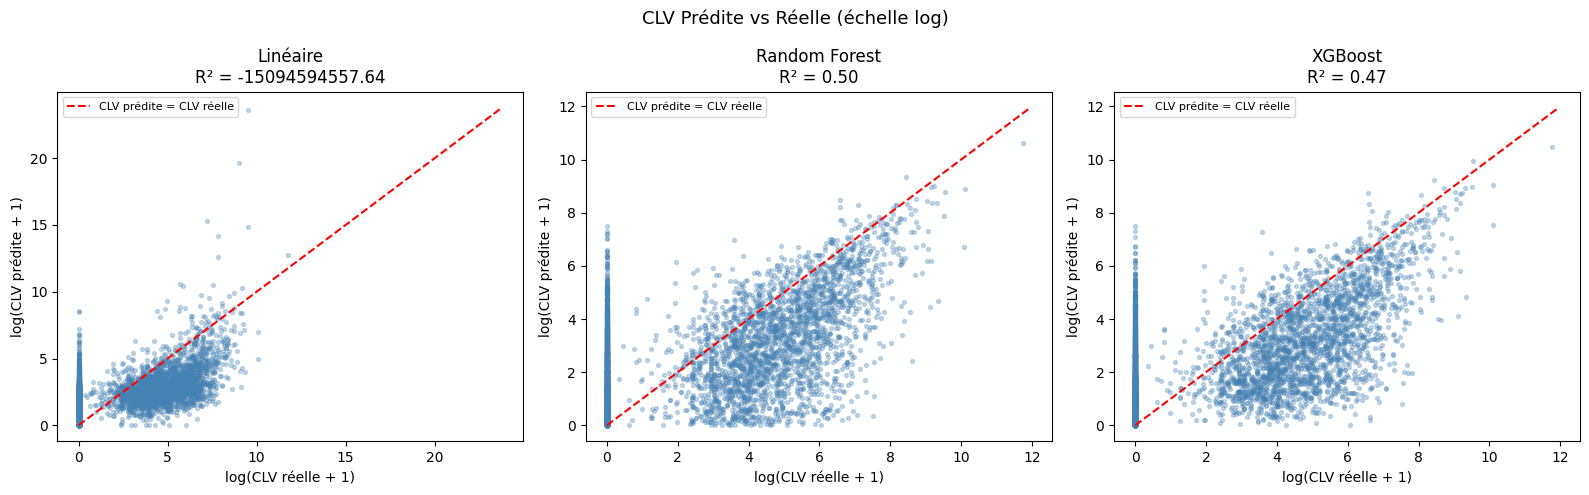

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, preds, nom in zip(axes, [preds_lr, preds_rf, preds_xgb], ["Linéaire", "Random Forest", "XGBoost"]):

    preds_clean = np.maximum(preds, 0)
    y_log    = np.log1p(y_test)
    pred_log = np.log1p(preds_clean)

    ax.scatter(y_log, pred_log, alpha=0.3, s=8, color="steelblue")

    max_val = max(y_log.max(), pred_log.max()) + 0.2
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label="CLV prédite = CLV réelle")

    r2 = r2_score(y_test, preds_clean)
    ax.set_xlabel("log(CLV réelle + 1)")
    ax.set_ylabel("log(CLV prédite + 1)")
    ax.set_title(f"{nom}\nR² = {r2:.2f}")
    ax.legend(fontsize=8)

plt.suptitle("CLV Prédite vs Réelle (échelle log)", fontsize=13)
plt.tight_layout()
plt.savefig("scatter_final.png", dpi=120, bbox_inches="tight")
plt.show()

Le modèle Random Forest est le plus performant avec un R² de 0,50. XGBoost obtient un R² de 0,47, ce qui reste très proche. En revanche, le modèle de régression linéaire présente un R² négatif, ce qui indique de très mauvaises performances et peut sembler incohérent. Concernant le Random Forest et le XGBoost, les résidus sont globalement bien distribués : les points suivent dans l’ensemble la tendance de la ligne rouge, ce qui suggère un bon ajustement du modèle.

In [82]:
import shap
meilleur_modele = xgb

C:\Users\LEOPO\AppData\Local\Temp\ipykernel_49220\3004749403.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, feature_names=feature_col)


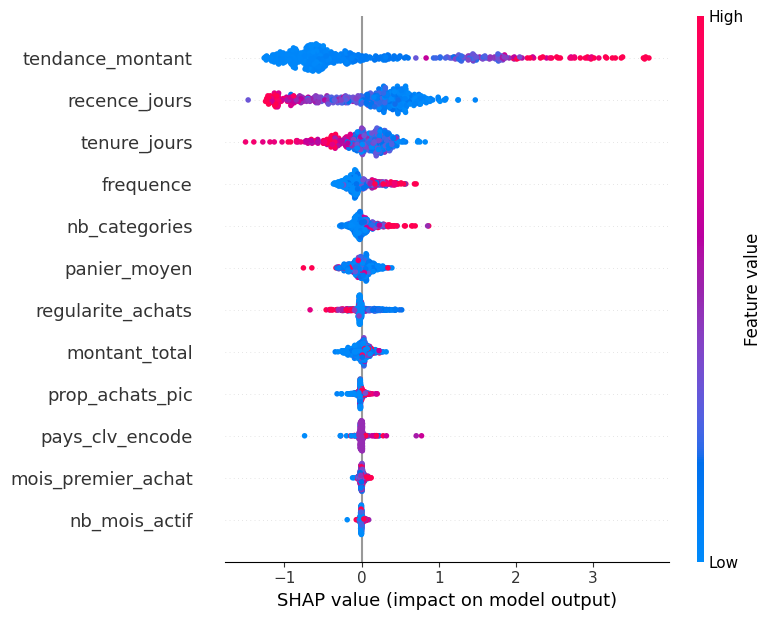

In [83]:
import shap
np.random.seed(5)
idx_sample  = np.random.choice(len(X_test), size=500, replace=False)
X_test_sample = X_test[idx_sample]

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values, X_test_sample, feature_names=feature_col)

Client CLV ÉLEVÉE  CLV prédite : 7.75 €


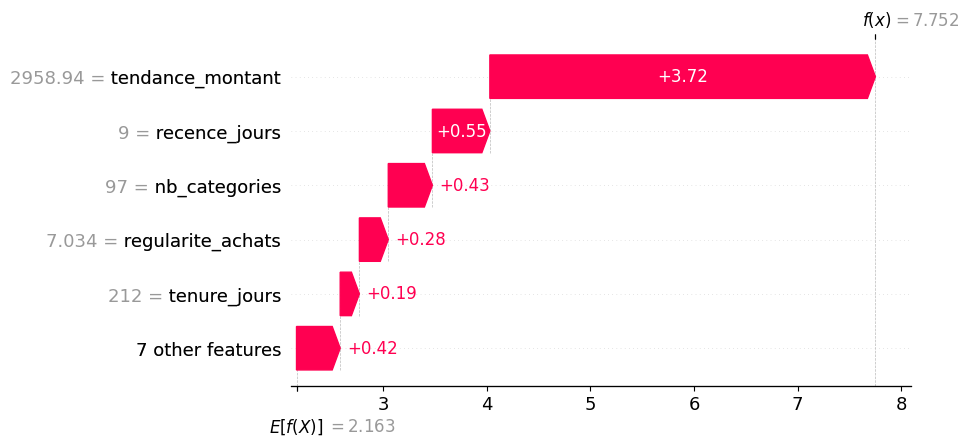

Client CLV MOYENNE  CLV prédite : 1.78 €


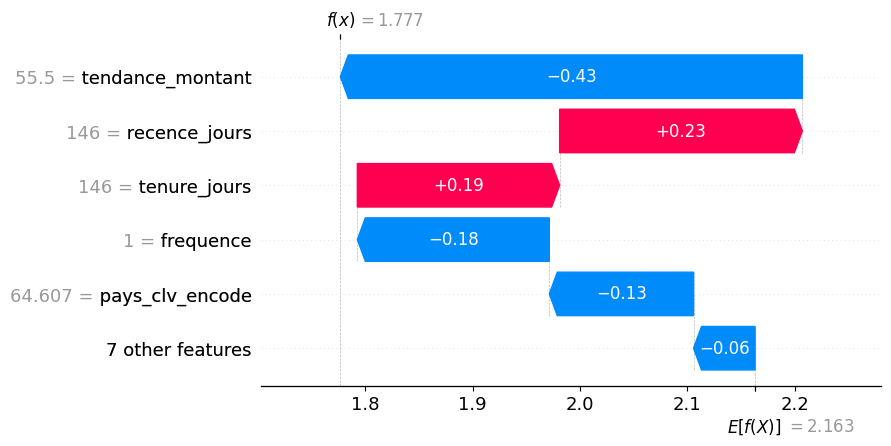

Client CLV BASSE  CLV prédite : 0.00 €


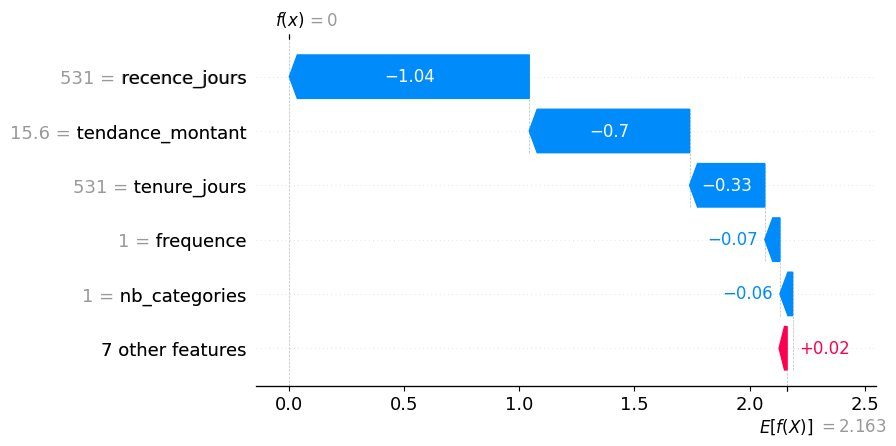

In [93]:
preds_sample = rf.predict(X_test_sample)
idx_haut  = np.argmax(preds_sample)
idx_moyen = np.argsort(preds_sample)[len(preds_sample)//2]
idx_bas   = np.argmin(preds_sample)

for label, idx in [("CLV ÉLEVÉE", idx_haut), ("CLV MOYENNE", idx_moyen), ("CLV BASSE", idx_bas)]:
    print(f"Client {label}  CLV prédite : {preds_sample[idx]:.2f} €")
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[idx],
            base_values   = explainer.expected_value,
            data          = X_test_sample[idx],
            feature_names = feature_col
        ),
        max_display=6
    )

Client à forte CLV :
Dépenses en forte progression
Achats récents
Consommation diversifiée (nombreuses catégories)
Grande régularité d’achat
Profil premium combinant croissance, diversité et fidélité

Client à CLV moyenne :
Comportement globalement neutre
Aucune variable réellement dominante
Achats occasionnels
Absence de tendance claire

Client à CLV nulle :
Faible probabilité de retour
Dernier achat ancien (récence élevée)
Faible fréquence d’achat
Dépenses faibles ou en diminution

In [85]:
shap_client = shap_values[idx]
top_features_idx = np.argsort(np.abs(shap_client))[-5:][::-1]
for fi in top_features_idx:
    direction = "up" if shap_client[fi] > 0 else "down"
    print(f"  {direction} {feature_col[fi]} = {X_test[idx, fi]:.2f} (impact SHAP: {shap_client[fi]:.2f})")

  down recence_jours = 274.00 (impact SHAP: -1.04)
  down tendance_montant = 63.44 (impact SHAP: -0.70)
  down tenure_jours = 274.00 (impact SHAP: -0.33)
  down frequence = 1.00 (impact SHAP: -0.07)
  down nb_categories = 9.00 (impact SHAP: -0.06)


les features les les plus actionnables au niveau marketing 
Récence_jour faire des relance par eamil si la commande est trop loin 
Tendance_montant : focus sur les clients dont les dépenses baisse.
frequence : analyser la fréquence d'achat


#### Segmentation par CLV

In [86]:
features_all = features[feature_col].values
features["clv_predite"] = meilleur_modele.predict(features_all)
features["clv_predite"] = features["clv_predite"].clip(lower=0)

In [87]:
#You can drop duplicate edges by setting the 'duplicates' kwarg to 'drop' or 'raise' (default is 'raise').
features["decile_clv"] = pd.qcut(features["clv_predite"], q=10, labels=False) + 1


In [88]:
print("CLV moyenne par décile :")
decile_stats = features.groupby("decile_clv").agg(
    nb_clients=("customer_id", "count"),
    clv_predite_moy=("clv_predite", "mean"),
    clv_predite_total=("clv_predite", "sum"),
    montant_obs_moy=("montant_total", "mean"),
    frequence_moy=("frequence", "mean"),
).round(2)
print(decile_stats)

CLV moyenne par décile :
            nb_clients  clv_predite_moy  clv_predite_total  montant_obs_moy  \
decile_clv                                                                    
1                 2854             0.07         198.699997            92.09   
2                 2861             0.36        1017.520020            79.11   
3                 2849             0.76        2165.570068            84.89   
4                 2851             1.13        3235.250000            64.81   
5                 2854             1.49        4251.779785            68.74   
6                 2853             1.90        5415.640137            98.65   
7                 2854             2.51        7154.620117           140.44   
8                 2853             3.20        9138.120117           225.53   
9                 2854             4.23       12065.709961           452.39   
10                2854             6.00       17135.800781          1888.36   

            frequence_moy 

### classement ROI

In [89]:
features["clv_predite_euros"] = np.expm1(features["clv_predite"])
top10 = features[features["decile_clv"] == 10]

nb_cibles      = len(top10)
cout_campagne  = nb_cibles * 2
ca_additionnel = top10["clv_predite_euros"].sum() * 0.15
roi            = (ca_additionnel - cout_campagne) / cout_campagne * 100

print(f"Clients ciblés         : {nb_cibles}")
print(f"CLV moyenne top 10%    : {top10['clv_predite_euros'].mean():.2f}")
print(f"Coût total campagne    : {cout_campagne:.2f} ")
print(f"CA additionnel (lift)  : {ca_additionnel:.2f} ")
print(f"ROI                    : {roi:.1f} ")

Clients ciblés         : 2854
CLV moyenne top 10%    : 830.02
Coût total campagne    : 5708.00 
CA additionnel (lift)  : 355333.59 
ROI                    : 6125.2 


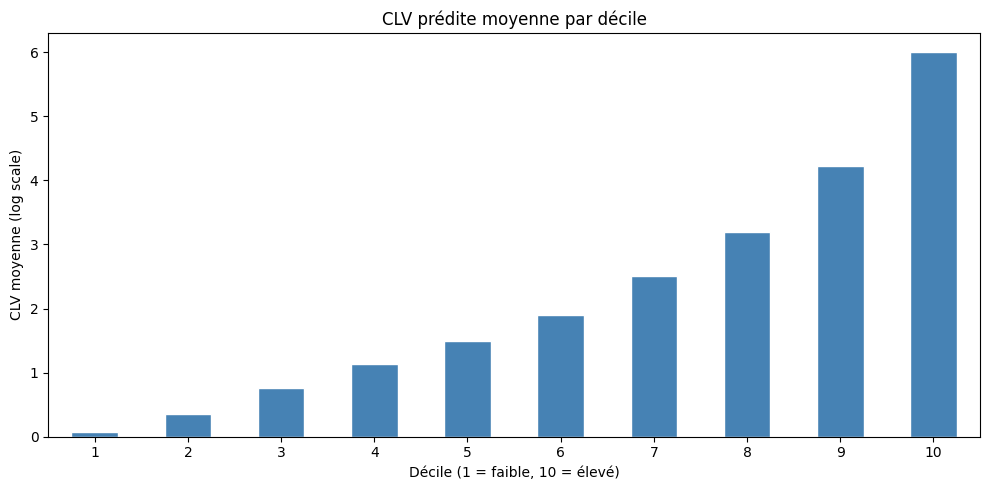

In [90]:
plt.figure(figsize=(10, 5))
decile_stats["clv_predite_moy"].plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("CLV prédite moyenne par décile")
plt.xlabel("Décile (1 = faible, 10 = élevé)")
plt.ylabel("CLV moyenne (log scale)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Déciles 1–3 (investisement null ou tres peu rentable )
CLV prédite envrion a 0
Fréquence très faible (1,2–1,5 achats)
Clients quasi-perdus



Déciles 4–6 toujours peu rentable et limité
CLV modérée 
Clients occasionnels

Déciles 7–9 (commence a être régulier donc bien axer dessus )
Clients réguliers
Fréquence croissante (2 à 3,75 achats)


Décile 10 (Forte concentration de valeur car les plus rentables)
2 854 clients
Fréquence moyenne : 8,27 achats
Montant moyen : 1 888 €
Segment VIP


ROI – (Top 10%)
Investissement très rentable peut de sortie pour beaucoup d'entrées
Rentabilité + élevée
Ciblage prioritaire des clients à forte CLV